# Test Best Model: LLVIP Test Set & My Dataset
Confusion Matrix + Continuous Score Distribution (KDE) per cada dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Configuration

In [ ]:
# C
project_path = "/content/drive/MyDrive/4t/3r trimestre/Aprenentatge Profund/UPF_Deep_Learning_2026/Final Project"
# M
# project_path = "/content/drive/MyDrive/4t/3r trimestre/Aprenentatge Profund/UPF_Deep_Learning_2026/Final Project"
# P
# project_path = "/content/drive/MyDrive/Colab Notebooks/DL/UPF_Deep_Learning_2026/Final Project"

model_name     = "best_model.pkt"
results_path   = project_path + "/results"
data_path      = project_path + "/data"
model_save_file = results_path + "/" + model_name

BATCH_SIZE = 32
SEED       = 42

# Imports & Setup

In [ ]:
import io
import os
import zipfile
import random
import shutil
from typing import Optional, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, UnidentifiedImageError

torch.manual_seed(SEED)
random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


# Class & Function Definitions

In [ ]:
# Apply torch.sigmoid
model_output_activation: Optional[Callable] = torch.sigmoid

In [ ]:
class ZipInfraredDataset(Dataset):
    def __init__(self, zip_path, csv_internal_path, images_prefix, transform=None):
        self.zip_path = zip_path
        self.images_prefix = images_prefix
        self.transform = transform
        with zipfile.ZipFile(self.zip_path, 'r') as z:
            with z.open(csv_internal_path) as f:
                self.annotations = pd.read_csv(f)

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        img_name = self.annotations.iloc[idx, 0]
        label    = self.annotations.iloc[idx, 1]
        img_path = os.path.join(self.images_prefix, img_name)
        with zipfile.ZipFile(self.zip_path, 'r') as z:
            with z.open(img_path) as f:
                image = Image.open(io.BytesIO(f.read())).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
class BetterInfraredCNN(nn.Module):
    def __init__(self):
        super(BetterInfraredCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.fc1   = nn.Linear(64, 32)
        self.fc2   = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.25)
        self.bn1   = nn.BatchNorm2d(16)
        self.bn2   = nn.BatchNorm2d(32)
        self.bn3   = nn.BatchNorm2d(64)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [ ]:
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


def collect_predictions(model, loader, device, activation):
    """Returns (labels, preds, scores) as numpy arrays."""
    model.eval()
    all_labels, all_preds, all_scores = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs  = activation(outputs) if activation is not None else outputs
            scores = probs.cpu().numpy().flatten()
            preds  = (probs > 0.5).float().cpu().numpy().flatten()
            all_scores.extend(scores)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy().flatten())
    return np.array(all_labels), np.array(all_preds), np.array(all_scores)


def plot_cm_and_kde(labels, preds, scores, title_suffix=""):
    """Side-by-side confusion matrix and KDE score distribution."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No Person', 'Person'],
                yticklabels=['No Person', 'Person'])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title(f'Confusion Matrix{title_suffix}')
    tn, fp, fn, tp = cm.ravel()
    print(f"[{title_suffix.strip()}]  TP={tp} | FP={fp} | FN={fn} | TN={tn}")
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds)
    print(f"[{title_suffix.strip()}]  Accuracy={acc:.4f} | F1={f1:.4f}")

    # KDE Score Distribution
    x_range   = np.linspace(0, 1, 500)
    scores_neg = scores[labels == 0]
    scores_pos = scores[labels == 1]
    if len(scores_neg) > 1:
        kde_neg = gaussian_kde(scores_neg, bw_method=0.1)
        y_neg   = kde_neg(x_range)
        axes[1].plot(x_range, y_neg, color='blue', lw=2, label='True: No Person')
        axes[1].fill_between(x_range, 0, y_neg, color='blue', alpha=0.3)
    if len(scores_pos) > 1:
        kde_pos = gaussian_kde(scores_pos, bw_method=0.1)
        y_pos   = kde_pos(x_range)
        axes[1].plot(x_range, y_pos, color='red', lw=2, label='True: Person')
        axes[1].fill_between(x_range, 0, y_pos, color='red', alpha=0.3)
    axes[1].axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
    axes[1].set_xlabel('Model Output Score (Probability)')
    axes[1].set_ylabel('Density')
    axes[1].set_title(f'Score Distribution (KDE){title_suffix}')
    axes[1].legend(loc='upper center')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

---
# LLVIP Test Set

CSV:    results_test/labels/dataset_labels.csv
Images: results_test/images
Model loaded from /content/drive/MyDrive/4t/3r trimestre/Aprenentatge Profund/UPF_Deep_Learning_2026/Final Project/results/best_model.pkt
[— LLVIP Test Set]  TP=4726 | FP=878 | FN=979 | TN=3632
[— LLVIP Test Set]  Accuracy=0.8182 | F1=0.8358


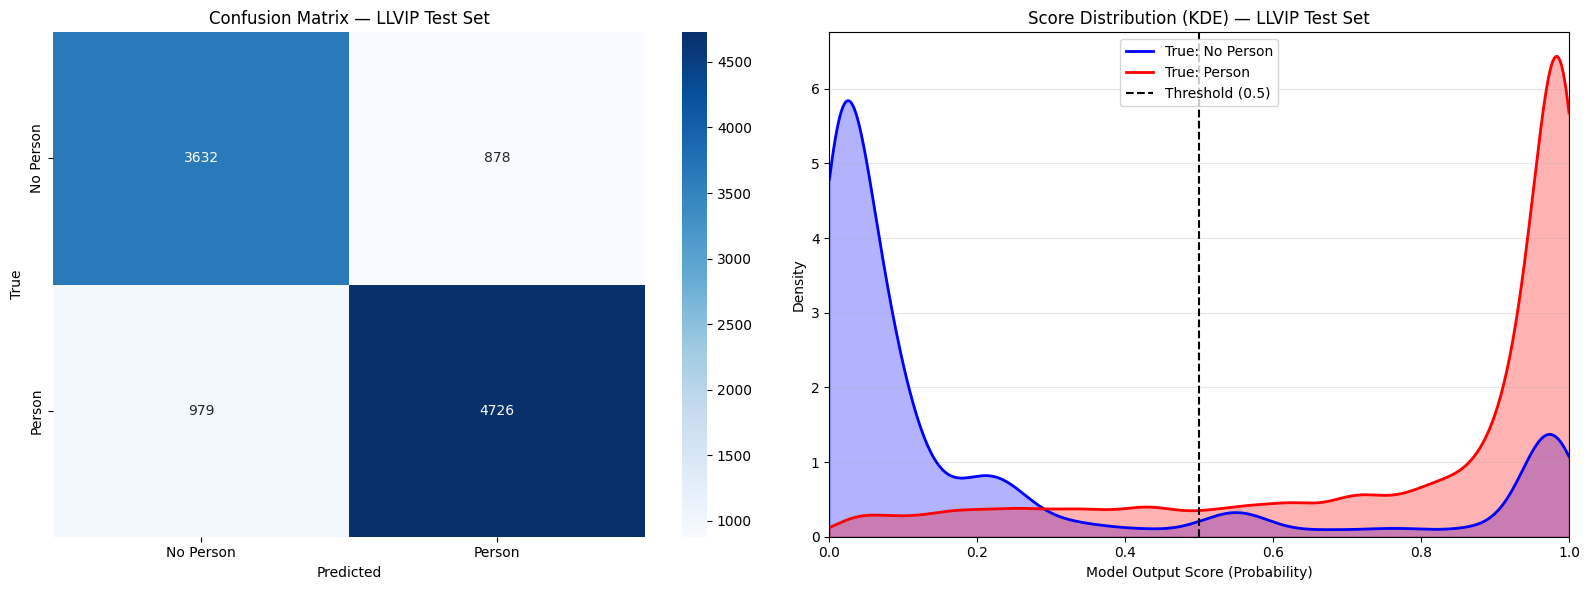

In [ ]:
test_zip_path = data_path + "/dataset_LLVIP/results_test.zip"

# Find internal paths inside the ZIP
with zipfile.ZipFile(test_zip_path, 'r') as z:
    all_files = z.namelist()
    csv_files = [f for f in all_files if f.endswith('dataset_labels.csv')]
    if not csv_files:
        raise FileNotFoundError("dataset_labels.csv not found inside test ZIP.")
    INTERNAL_CSV  = csv_files[0]
    INTERNAL_IMGS = os.path.join(os.path.dirname(os.path.dirname(INTERNAL_CSV)), "images")

print(f"CSV:    {INTERNAL_CSV}")
print(f"Images: {INTERNAL_IMGS}")

llvip_dataset = ZipInfraredDataset(
    zip_path=test_zip_path,
    csv_internal_path=INTERNAL_CSV,
    images_prefix=INTERNAL_IMGS,
    transform=eval_transforms
)
llvip_loader = DataLoader(llvip_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Load best model
llvip_model = BetterInfraredCNN()
llvip_model.load_state_dict(torch.load(model_save_file, map_location=device))
llvip_model.to(device)
llvip_model.eval()
print(f"Model loaded from {model_save_file}")

# Evaluate
labels_llvip, preds_llvip, scores_llvip = collect_predictions(
    llvip_model, llvip_loader, device, model_output_activation
)

# Plots
plot_cm_and_kde(labels_llvip, preds_llvip, scores_llvip, title_suffix=" — LLVIP Test Set")

---
# My Dataset

In [ ]:
EVAL_IMAGES_ZIP  = project_path + "/data/my_dataset/images-20260531T151811Z-3-001.zip"
DRIVE_LABELS_CSV = project_path + "/data/my_dataset/labels/labels_claradataset.csv"

LOCAL_BASE   = "/content/my_dataset_eval"
LOCAL_IMAGES = os.path.join(LOCAL_BASE, "images")
LOCAL_LABELS = os.path.join(LOCAL_BASE, "labels")
LOCAL_CSV    = os.path.join(LOCAL_LABELS, "labels_claradataset.csv")

# Extract images locally for faster loading
if os.path.exists(LOCAL_BASE):
    shutil.rmtree(LOCAL_BASE)
os.makedirs(LOCAL_IMAGES, exist_ok=True)
os.makedirs(LOCAL_LABELS, exist_ok=True)

print("Extracting images...")
temp_dir = "/content/temp_mydata"
os.makedirs(temp_dir, exist_ok=True)
with zipfile.ZipFile(EVAL_IMAGES_ZIP, 'r') as zf:
    zf.extractall(temp_dir)
moved = 0
for item in os.listdir(temp_dir):
    item_path = os.path.join(temp_dir, item)
    if os.path.isdir(item_path):
        for sub in os.listdir(item_path):
            shutil.move(os.path.join(item_path, sub), LOCAL_IMAGES)
            moved += 1
    elif item.lower().endswith(('.jpg', '.jpeg')):
        shutil.move(item_path, LOCAL_IMAGES)
        moved += 1
shutil.rmtree(temp_dir)
print(f"{moved} images extracted to {LOCAL_IMAGES}")

shutil.copy(DRIVE_LABELS_CSV, LOCAL_CSV)
print(f"Labels CSV copied to {LOCAL_CSV}")

Extracting images...
1333 images extracted to /content/my_dataset_eval/images
Labels CSV copied to /content/my_dataset_eval/labels/labels_claradataset.csv


1333 valid images loaded
Model loaded from /content/drive/MyDrive/4t/3r trimestre/Aprenentatge Profund/UPF_Deep_Learning_2026/Final Project/results/best_model.pkt
[— My Dataset]  TP=140 | FP=0 | FN=838 | TN=355
[— My Dataset]  Accuracy=0.3713 | F1=0.2504


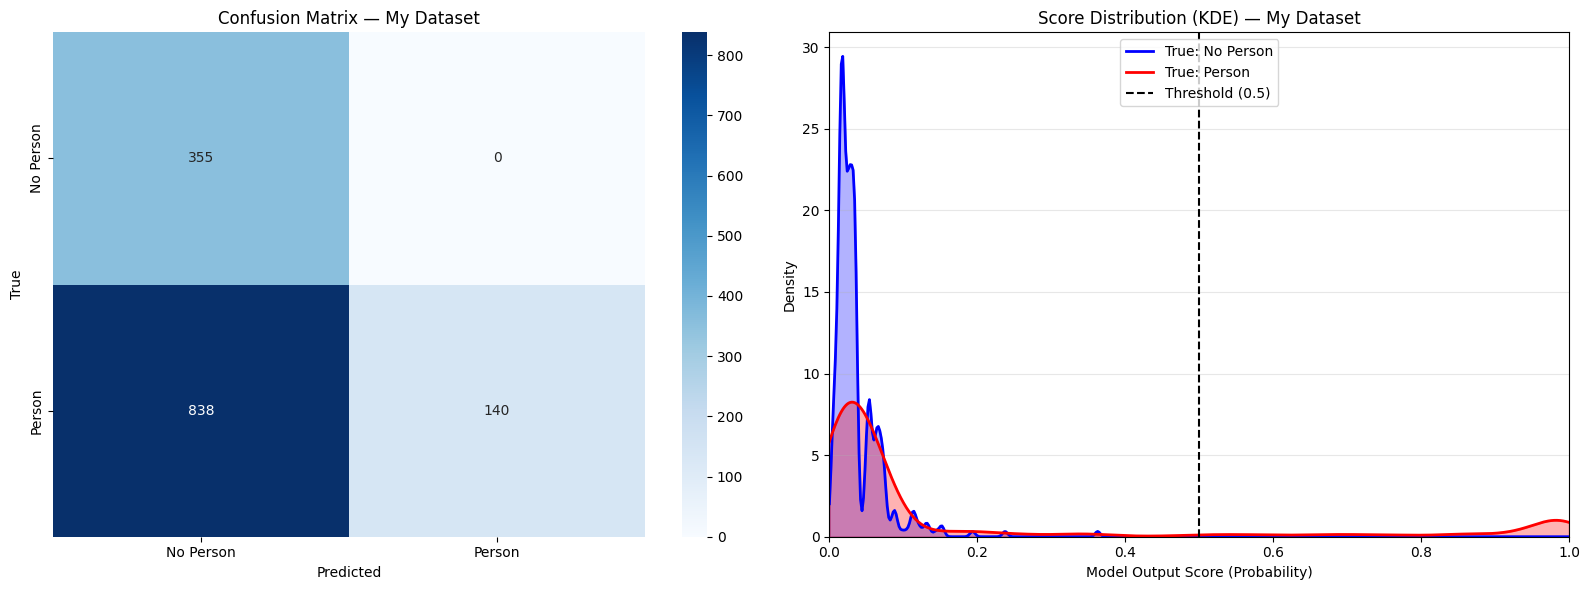

In [ ]:
class MyDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None):
        self.annotations = pd.read_csv(csv_path, header=None)
        self.images_dir  = images_dir
        self.transform   = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        basename = str(self.annotations.iloc[idx, 0])
        label    = self.annotations.iloc[idx, 1]
        for ext in ('.JPG', '.jpg', '.jpeg', '.JPEG'):
            path = os.path.join(self.images_dir, basename + ext)
            if os.path.exists(path):
                try:
                    image = Image.open(path).convert('L')
                    if self.transform:
                        image = self.transform(image)
                    return image, label
                except (UnidentifiedImageError, IOError):
                    return None, None
        return None, None


class FilteredDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]


my_eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

raw_ds  = MyDataset(LOCAL_CSV, LOCAL_IMAGES, transform=my_eval_transforms)
valid   = [(img, lbl) for img, lbl in raw_ds if img is not None]
my_ds   = FilteredDataset(valid)
my_loader = DataLoader(my_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=torch.cuda.is_available())
print(f"{len(my_ds)} valid images loaded")

# Load best model (same checkpoint)
my_model = BetterInfraredCNN()
my_model.load_state_dict(torch.load(model_save_file, map_location=device))
my_model.to(device)
my_model.eval()
print(f"Model loaded from {model_save_file}")

# Evaluate
labels_my, preds_my, scores_my = collect_predictions(
    my_model, my_loader, device, model_output_activation
)

# Plots
plot_cm_and_kde(labels_my, preds_my, scores_my, title_suffix=" — My Dataset")